# 02 — Preprocessing and feature extraction

This notebook creates the two feature tables used for the report analyses:

- `data_processed/recording_features.csv`
- `data_processed/epoch_features.csv`

The pipeline:

1. Load each EDF file listed in `manifest.csv`.
2. Keep EEG channels only, excluding the `Status` channel.
3. Apply a 50 Hz notch filter.
4. Apply a 1–40 Hz band-pass filter.
5. Split the recording into non-overlapping 30-second epochs.
6. Reject epochs with extreme peak-to-peak amplitude.
7. Compute PSD features.
8. Extract alpha-band features and other simple spectral features.

The main feature is posterior alpha power in the 8–12 Hz band.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from scipy.signal import welch
from tqdm.auto import tqdm

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Change this only if the project folder moves.
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")

MANIFEST_FILE = PROJECT_ROOT / "data_processed" / "manifest.csv"
PROCESSED_DIR = PROJECT_ROOT / "data_processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

PROCESSED_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RECORDING_FEATURES_FILE = PROCESSED_DIR / "recording_features.csv"
EPOCH_FEATURES_FILE = PROCESSED_DIR / "epoch_features.csv"

manifest = pd.read_csv(MANIFEST_FILE)

print("Manifest shape:", manifest.shape)
manifest.head()


Manifest shape: (1216, 11)


,recording_id,participant_id,pair_id,session,acquisition,condition,age,sex,handedness,eeg_path,complete_pair
0,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,1,pre,EC,60,F,right,data/ds005385/sub-001/ses-1/eeg/sub-001_ses-1_...,True
1,sub-001_ses-1_pre_EO,sub-001,sub-001_ses-1_pre,1,pre,EO,60,F,right,data/ds005385/sub-001/ses-1/eeg/sub-001_ses-1_...,True
2,sub-002_ses-1_pre_EC,sub-002,sub-002_ses-1_pre,1,pre,EC,67,M,right,data/ds005385/sub-002/ses-1/eeg/sub-002_ses-1_...,True
3,sub-002_ses-1_pre_EO,sub-002,sub-002_ses-1_pre,1,pre,EO,67,M,right,data/ds005385/sub-002/ses-1/eeg/sub-002_ses-1_...,True
4,sub-003_ses-1_pre_EC,sub-003,sub-003_ses-1_pre,1,pre,EC,44,F,right,data/ds005385/sub-003/ses-1/eeg/sub-003_ses-1_...,True


## 1. Fixed preprocessing and feature settings

These settings should remain fixed before the final analyses.


In [2]:
# Preprocessing
NOTCH_FREQ = 50
L_FREQ = 1
H_FREQ = 40

# Epoching
EPOCH_LENGTH_SEC = 30
EPOCH_OVERLAP_SEC = 0

# Simple epoch rejection threshold.
# MNE stores EEG in volts. 500 µV = 500e-6 V.
PTP_REJECT_THRESHOLD_V = 500e-6

# PSD settings
PSD_FMIN = 1
PSD_FMAX = 40
WELCH_WINDOW_SEC = 4
WELCH_OVERLAP_SEC = 2

# Frequency bands
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (13, 30),
    "high_beta": (30, 40),
}

# Channel sets fixed from the inspection notebook.
OZ_CHANNELS = ["Oz"]

OCCIPITAL_CHANNELS = ["O1", "Oz", "O2"]

POSTERIOR_CHANNELS = [
    "P7", "P3", "Pz", "P4", "P8",
    "PO9", "O1", "Oz", "O2", "PO10",
    "P5", "P1", "P2", "P6",
    "PO7", "PO3", "POz", "PO4", "PO8",
]

print("N posterior channels:", len(POSTERIOR_CHANNELS))


N posterior channels: 19


## 2. Helper functions

In [3]:
def load_raw_eeg(row, preload=True):
    """Load one EDF recording and keep EEG channels only."""
    eeg_file = PROJECT_ROOT / row["eeg_path"]
    raw = mne.io.read_raw_edf(eeg_file, preload=preload, verbose=False)
    raw.pick("eeg")  # excludes Status/stim channel
    return raw


def preprocess_raw(raw):
    """Apply the fixed preprocessing pipeline."""
    raw = raw.copy().load_data()
    raw.notch_filter(freqs=NOTCH_FREQ, verbose=False)
    raw.filter(
        l_freq=L_FREQ,
        h_freq=H_FREQ,
        method="fir",
        phase="zero",
        verbose=False,
    )
    return raw


def make_fixed_length_epochs_array(raw):
    """Return non-overlapping epoch data as array: epochs x channels x samples."""
    sfreq = raw.info["sfreq"]
    epoch_samples = int(EPOCH_LENGTH_SEC * sfreq)
    step_samples = int((EPOCH_LENGTH_SEC - EPOCH_OVERLAP_SEC) * sfreq)

    data = raw.get_data()  # channels x samples
    n_samples = data.shape[1]

    starts = np.arange(0, n_samples - epoch_samples + 1, step_samples)

    epochs = []
    for start in starts:
        stop = start + epoch_samples
        epochs.append(data[:, start:stop])

    if len(epochs) == 0:
        return np.empty((0, data.shape[0], epoch_samples)), starts

    return np.stack(epochs, axis=0), starts


def epoch_qc_mask(epoch_data):
    """Reject epochs with excessive peak-to-peak amplitude in any EEG channel."""
    # epoch_data shape: epochs x channels x samples
    if epoch_data.shape[0] == 0:
        return np.array([], dtype=bool), np.array([])

    ptp_per_epoch_channel = np.ptp(epoch_data, axis=2)
    max_ptp_per_epoch = ptp_per_epoch_channel.max(axis=1)

    keep_mask = max_ptp_per_epoch <= PTP_REJECT_THRESHOLD_V
    return keep_mask, max_ptp_per_epoch


def compute_epoch_psd(epoch, sfreq):
    """Compute Welch PSD for one epoch.

    Input:
        epoch: channels x samples, in volts

    Returns:
        freqs: frequency vector
        psd: channels x frequencies, in V^2/Hz
    """
    nperseg = int(WELCH_WINDOW_SEC * sfreq)
    noverlap = int(WELCH_OVERLAP_SEC * sfreq)

    freqs, psd = welch(
        epoch,
        fs=sfreq,
        nperseg=nperseg,
        noverlap=noverlap,
        axis=-1,
        detrend="constant",
        scaling="density",
    )

    freq_mask = (freqs >= PSD_FMIN) & (freqs <= PSD_FMAX)
    return freqs[freq_mask], psd[:, freq_mask]


def bandpower_from_psd(freqs, psd, fmin, fmax):
    """Integrate PSD within a frequency band.

    psd can be channels x freqs or freqs.
    """
    mask = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(mask):
        return np.nan

    return np.trapz(psd[..., mask], freqs[mask], axis=-1)


def safe_log10(x):
    """Log-transform positive power values safely."""
    return np.log10(np.maximum(x, np.finfo(float).tiny))


def get_existing_channels(raw, channel_list):
    """Return requested channels that exist in this recording."""
    return [ch for ch in channel_list if ch in raw.ch_names]


def summarize_channel_set(freqs, psd, ch_names, channel_set, prefix):
    """Compute alpha and relative alpha features for a channel set."""
    existing = [ch for ch in channel_set if ch in ch_names]

    features = {
        f"{prefix}_n_channels": len(existing),
    }

    if len(existing) == 0:
        features.update({
            f"{prefix}_alpha_abs": np.nan,
            f"{prefix}_alpha_log": np.nan,
            f"{prefix}_total_1_40_abs": np.nan,
            f"{prefix}_alpha_rel": np.nan,
        })
        return features

    picks = [ch_names.index(ch) for ch in existing]
    mean_psd = psd[picks, :].mean(axis=0)

    alpha = bandpower_from_psd(freqs, mean_psd, 8, 12)
    total = bandpower_from_psd(freqs, mean_psd, 1, 40)

    features.update({
        f"{prefix}_alpha_abs": alpha,
        f"{prefix}_alpha_log": safe_log10(alpha),
        f"{prefix}_total_1_40_abs": total,
        f"{prefix}_alpha_rel": alpha / total if total > 0 else np.nan,
    })

    return features


def extract_features_from_epoch(freqs, psd, ch_names):
    """Extract report-relevant spectral features from one clean epoch."""
    features = {}

    # Main channel sets
    features.update(summarize_channel_set(freqs, psd, ch_names, OZ_CHANNELS, "oz"))
    features.update(summarize_channel_set(freqs, psd, ch_names, OCCIPITAL_CHANNELS, "occipital"))
    features.update(summarize_channel_set(freqs, psd, ch_names, POSTERIOR_CHANNELS, "posterior"))

    # Posterior band powers: useful for simple multifeature models later.
    existing_posterior = [ch for ch in POSTERIOR_CHANNELS if ch in ch_names]
    if len(existing_posterior) > 0:
        picks = [ch_names.index(ch) for ch in existing_posterior]
        posterior_mean_psd = psd[picks, :].mean(axis=0)

        total = bandpower_from_psd(freqs, posterior_mean_psd, 1, 40)

        for band_name, (fmin, fmax) in BANDS.items():
            power = bandpower_from_psd(freqs, posterior_mean_psd, fmin, fmax)
            features[f"posterior_{band_name}_abs"] = power
            features[f"posterior_{band_name}_log"] = safe_log10(power)
            features[f"posterior_{band_name}_rel"] = power / total if total > 0 else np.nan

        # Individual posterior channel alpha powers.
        for ch in existing_posterior:
            ch_idx = ch_names.index(ch)
            ch_alpha = bandpower_from_psd(freqs, psd[ch_idx, :], 8, 12)
            safe_ch = ch.replace("-", "_")
            features[f"ch_{safe_ch}_alpha_log"] = safe_log10(ch_alpha)

    return features


## 3. Process one recording as a test

Before processing all files, test the pipeline on one EC recording.


In [4]:
test_row = manifest.query("participant_id == 'sub-001' and condition == 'EC'").iloc[0]

raw = load_raw_eeg(test_row)
raw_filt = preprocess_raw(raw)

epochs, starts = make_fixed_length_epochs_array(raw_filt)
keep_mask, max_ptp = epoch_qc_mask(epochs)

print("Recording:", test_row["recording_id"])
print("Sampling frequency:", raw_filt.info["sfreq"])
print("EEG channels:", len(raw_filt.ch_names))
print("Epoch array shape:", epochs.shape)
print("Total epochs:", len(epochs))
print("Retained epochs:", keep_mask.sum())
print("Rejected epochs:", (~keep_mask).sum())
print("Max peak-to-peak amplitude per epoch, µV:")
print(np.round(max_ptp * 1e6, 2))


Recording: sub-001_ses-1_pre_EC
Sampling frequency: 1000.0
EEG channels: 64
Epoch array shape: (6, 64, 30000)
Total epochs: 6
Retained epochs: 6
Rejected epochs: 0
Max peak-to-peak amplitude per epoch, µV:
[127.63 158.44 357.83 337.83 372.64 128.21]


In [5]:
# Extract features for the first retained epoch.
first_good_epoch = epochs[keep_mask][0]

freqs, psd = compute_epoch_psd(first_good_epoch, raw_filt.info["sfreq"])
features = extract_features_from_epoch(freqs, psd, raw_filt.ch_names)

pd.Series(features).head(30)


C:\Users\maria\AppData\Local\Temp\ipykernel_28384\4151925828.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[..., mask], freqs[mask], axis=-1)


oz_n_channels               1.000000e+00
oz_alpha_abs                1.061805e-10
oz_alpha_log               -9.973955e+00
oz_total_1_40_abs           1.761438e-10
oz_alpha_rel                6.028058e-01
occipital_n_channels        3.000000e+00
occipital_alpha_abs         1.545875e-10
occipital_alpha_log        -9.810826e+00
occipital_total_1_40_abs    2.314498e-10
occipital_alpha_rel         6.679096e-01
posterior_n_channels        1.900000e+01
posterior_alpha_abs         1.074240e-10
posterior_alpha_log        -9.968899e+00
posterior_total_1_40_abs    1.766822e-10
posterior_alpha_rel         6.080069e-01
posterior_delta_abs         1.520615e-11
posterior_delta_log        -1.081798e+01
posterior_delta_rel         8.606498e-02
posterior_theta_abs         8.917008e-12
posterior_theta_log        -1.104978e+01
posterior_theta_rel         5.046918e-02
posterior_beta_abs          3.879998e-11
posterior_beta_log         -1.041117e+01
posterior_beta_rel          2.196032e-01
posterior_high_b

## 4. Visual check: retained vs rejected epochs

This plot helps check whether the 500 µV threshold is too strict or too lenient.


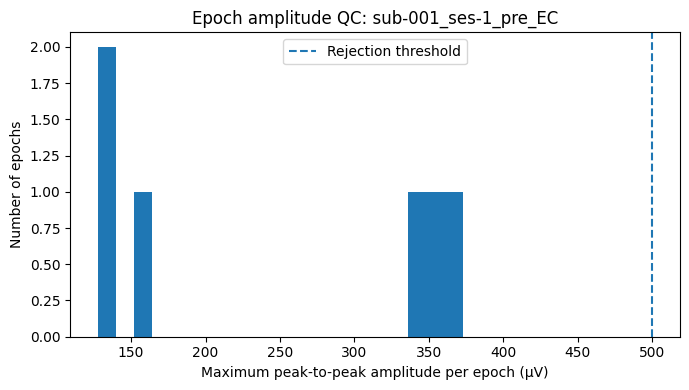

In [6]:
plt.figure(figsize=(7, 4))
plt.hist(max_ptp * 1e6, bins=20)
plt.axvline(PTP_REJECT_THRESHOLD_V * 1e6, linestyle="--", label="Rejection threshold")
plt.xlabel("Maximum peak-to-peak amplitude per epoch (µV)")
plt.ylabel("Number of epochs")
plt.title(f"Epoch amplitude QC: {test_row['recording_id']}")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Function to process one recording

In [7]:
def process_one_recording(row):
    """Preprocess one recording and return recording-level and epoch-level features."""
    base_info = {
        "recording_id": row["recording_id"],
        "participant_id": row["participant_id"],
        "pair_id": row["pair_id"],
        "condition": row["condition"],
        "age": row.get("age", np.nan),
        "sex": row.get("sex", np.nan),
        "handedness": row.get("handedness", np.nan),
    }

    try:
        raw = load_raw_eeg(row, preload=True)
        raw_filt = preprocess_raw(raw)

        sfreq = raw_filt.info["sfreq"]
        ch_names = raw_filt.ch_names

        epochs, starts = make_fixed_length_epochs_array(raw_filt)
        keep_mask, max_ptp = epoch_qc_mask(epochs)

        n_epochs_total = len(epochs)
        n_epochs_retained = int(keep_mask.sum())
        retained_fraction = (
            n_epochs_retained / n_epochs_total
            if n_epochs_total > 0 else np.nan
        )

        epoch_rows = []

        for epoch_index, epoch in enumerate(epochs):
            is_retained = bool(keep_mask[epoch_index])
            epoch_start_sec = starts[epoch_index] / sfreq

            epoch_info = {
                **base_info,
                "epoch_index": epoch_index,
                "epoch_start_sec": epoch_start_sec,
                "epoch_retained": is_retained,
                "max_ptp_uv": max_ptp[epoch_index] * 1e6,
            }

            if is_retained:
                freqs, psd = compute_epoch_psd(epoch, sfreq)
                epoch_features = extract_features_from_epoch(freqs, psd, ch_names)
                epoch_info.update(epoch_features)

            epoch_rows.append(epoch_info)

        epoch_df = pd.DataFrame(epoch_rows)

        retained_epoch_df = epoch_df[epoch_df["epoch_retained"]].copy()

        recording_info = {
            **base_info,
            "sfreq": sfreq,
            "duration_sec": raw_filt.times[-1],
            "n_eeg_channels": len(ch_names),
            "n_epochs_total": n_epochs_total,
            "n_epochs_retained": n_epochs_retained,
            "n_epochs_rejected": n_epochs_total - n_epochs_retained,
            "retained_fraction": retained_fraction,
            "include": n_epochs_retained > 0,
            "exclusion_reason": "" if n_epochs_retained > 0 else "no_retained_epochs",
        }

        # Average feature values across retained epochs.
        feature_cols = [
            col for col in retained_epoch_df.columns
            if (
                col.endswith("_abs")
                or col.endswith("_log")
                or col.endswith("_rel")
                or col.endswith("_n_channels")
                or col.startswith("ch_")
            )
        ]

        if n_epochs_retained > 0:
            feature_means = retained_epoch_df[feature_cols].mean(numeric_only=True)
            recording_info.update(feature_means.to_dict())

        recording_df = pd.DataFrame([recording_info])

        return recording_df, epoch_df, None

    except Exception as error:
        recording_info = {
            **base_info,
            "sfreq": np.nan,
            "duration_sec": np.nan,
            "n_eeg_channels": np.nan,
            "n_epochs_total": np.nan,
            "n_epochs_retained": 0,
            "n_epochs_rejected": np.nan,
            "retained_fraction": 0,
            "include": False,
            "exclusion_reason": str(error),
        }

        return pd.DataFrame([recording_info]), pd.DataFrame(), str(error)


## 6. Test the function on a few recordings

In [8]:
test_manifest = manifest[
    manifest["participant_id"].isin(["sub-001", "sub-002"])
].copy()

test_recording_dfs = []
test_epoch_dfs = []
test_errors = []

for _, row in tqdm(test_manifest.iterrows(), total=len(test_manifest)):
    rec_df, ep_df, error = process_one_recording(row)
    test_recording_dfs.append(rec_df)
    test_epoch_dfs.append(ep_df)

    if error is not None:
        test_errors.append({
            "recording_id": row["recording_id"],
            "error": error,
        })

test_recording_features = pd.concat(test_recording_dfs, ignore_index=True)
test_epoch_features = pd.concat(test_epoch_dfs, ignore_index=True)

test_recording_features[[
    "recording_id",
    "condition",
    "n_epochs_total",
    "n_epochs_retained",
    "retained_fraction",
    "posterior_alpha_log",
    "oz_alpha_log",
    "occipital_alpha_log",
]]


  0%|          | 0/4 [00:00<?, ?it/s]

C:\Users\maria\AppData\Local\Temp\ipykernel_28384\4151925828.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[..., mask], freqs[mask], axis=-1)
C:\Users\maria\AppData\Local\Temp\ipykernel_28384\4151925828.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[..., mask], freqs[mask], axis=-1)
C:\Users\maria\AppData\Local\Temp\ipykernel_28384\4151925828.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[..., mask], freqs[mask], axis=-1)
C:\Users\maria\AppData\Local\Temp\ipykernel_28384\4151925828.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trap

,recording_id,condition,n_epochs_total,n_epochs_retained,retained_fraction,posterior_alpha_log,oz_alpha_log,occipital_alpha_log
0,sub-001_ses-1_pre_EC,EC,6,6,1.000000,-10.070651,-10.175801,-9.970431
1,sub-001_ses-1_pre_EO,EO,6,5,0.833333,-10.935722,-10.959611,-10.901564
2,sub-002_ses-1_pre_EC,EC,6,6,1.000000,-10.093279,-10.022654,-9.960586
3,sub-002_ses-1_pre_EO,EO,6,5,0.833333,-11.024193,-11.107493,-11.048268


In [9]:
print("Test epoch features shape:", test_epoch_features.shape)
print("Errors:", test_errors)

test_epoch_features[[
    "recording_id",
    "condition",
    "epoch_index",
    "epoch_retained",
    "max_ptp_uv",
    "posterior_alpha_log",
]].head(12)


Test epoch features shape: (24, 57)
Errors: []


,recording_id,condition,epoch_index,epoch_retained,max_ptp_uv,posterior_alpha_log
0,sub-001_ses-1_pre_EC,EC,0,True,127.633285,-9.968899
1,sub-001_ses-1_pre_EC,EC,1,True,158.436027,-10.113561
2,sub-001_ses-1_pre_EC,EC,2,True,357.833316,-10.119880
3,sub-001_ses-1_pre_EC,EC,3,True,337.828244,-10.048713
4,sub-001_ses-1_pre_EC,EC,4,True,372.641703,-10.128217
5,sub-001_ses-1_pre_EC,EC,5,True,128.208840,-10.044638
6,sub-001_ses-1_pre_EO,EO,0,True,195.252702,-10.851175
7,sub-001_ses-1_pre_EO,EO,1,True,263.813701,-11.027529
8,sub-001_ses-1_pre_EO,EO,2,True,268.892606,-11.054836
9,sub-001_ses-1_pre_EO,EO,3,True,220.447723,-10.960310


## 7. Run feature extraction on all recordings

This may take some time because it loads, filters, epochs, and computes PSD for 1216 recordings.

If you want to test runtime first, change `RUN_ALL = False`.


In [10]:
RUN_ALL = True

if RUN_ALL:
    recording_dfs = []
    epoch_dfs = []
    error_rows = []

    for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
        rec_df, ep_df, error = process_one_recording(row)

        recording_dfs.append(rec_df)

        if len(ep_df) > 0:
            epoch_dfs.append(ep_df)

        if error is not None:
            error_rows.append({
                "recording_id": row["recording_id"],
                "participant_id": row["participant_id"],
                "condition": row["condition"],
                "error": error,
            })

    recording_features = pd.concat(recording_dfs, ignore_index=True)
    epoch_features = pd.concat(epoch_dfs, ignore_index=True)

    recording_features.to_csv(RECORDING_FEATURES_FILE, index=False)
    epoch_features.to_csv(EPOCH_FEATURES_FILE, index=False)

    print("Saved:", RECORDING_FEATURES_FILE)
    print("Saved:", EPOCH_FEATURES_FILE)

    print("\nRecording features shape:", recording_features.shape)
    print("Epoch features shape:", epoch_features.shape)

    if len(error_rows) > 0:
        errors_df = pd.DataFrame(error_rows)
        errors_file = PROCESSED_DIR / "feature_extraction_errors.csv"
        errors_df.to_csv(errors_file, index=False)
        print("Errors saved to:", errors_file)
        display(errors_df.head())
    else:
        print("No processing errors.")
else:
    print("RUN_ALL is False. Full feature extraction was skipped.")


  0%|          | 0/1216 [00:00<?, ?it/s]

C:\Users\maria\AppData\Local\Temp\ipykernel_28384\4151925828.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[..., mask], freqs[mask], axis=-1)
C:\Users\maria\AppData\Local\Temp\ipykernel_28384\4151925828.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[..., mask], freqs[mask], axis=-1)
C:\Users\maria\AppData\Local\Temp\ipykernel_28384\4151925828.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[..., mask], freqs[mask], axis=-1)
C:\Users\maria\AppData\Local\Temp\ipykernel_28384\4151925828.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trap

Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\recording_features.csv
Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\epoch_features.csv

Recording features shape: (1216, 62)
Epoch features shape: (7341, 57)
No processing errors.


## 8. Basic feature-extraction summary

In [11]:
if RECORDING_FEATURES_FILE.exists():
    recording_features = pd.read_csv(RECORDING_FEATURES_FILE)
    epoch_features = pd.read_csv(EPOCH_FEATURES_FILE)

    print("Recording features:", recording_features.shape)
    print("Epoch features:", epoch_features.shape)

    display(recording_features[[
        "recording_id",
        "condition",
        "n_epochs_total",
        "n_epochs_retained",
        "retained_fraction",
        "include",
        "posterior_alpha_log",
        "oz_alpha_log",
        "occipital_alpha_log",
    ]].head())

    display(recording_features[[
        "n_epochs_total",
        "n_epochs_retained",
        "n_epochs_rejected",
        "retained_fraction",
    ]].describe())
else:
    print("Feature files not found yet.")


Recording features: (1216, 62)
Epoch features: (7341, 57)


,recording_id,condition,n_epochs_total,n_epochs_retained,retained_fraction,include,posterior_alpha_log,oz_alpha_log,occipital_alpha_log
0,sub-001_ses-1_pre_EC,EC,6,6,1.000000,True,-10.070651,-10.175801,-9.970431
1,sub-001_ses-1_pre_EO,EO,6,5,0.833333,True,-10.935722,-10.959611,-10.901564
2,sub-002_ses-1_pre_EC,EC,6,6,1.000000,True,-10.093279,-10.022654,-9.960586
3,sub-002_ses-1_pre_EO,EO,6,5,0.833333,True,-11.024193,-11.107493,-11.048268
4,sub-003_ses-1_pre_EC,EC,7,7,1.000000,True,-10.851223,-10.711743,-10.694674


,n_epochs_total,n_epochs_retained,n_epochs_rejected,retained_fraction
count,1216.000000,1216.000000,1216.000000,1216.000000
mean,6.037007,5.746711,0.290296,0.952675
std,0.265018,0.869221,0.878891,0.140766
min,2.000000,0.000000,0.000000,0.000000
25%,6.000000,6.000000,0.000000,1.000000
50%,6.000000,6.000000,0.000000,1.000000
75%,6.000000,6.000000,0.000000,1.000000
max,9.000000,9.000000,8.000000,1.000000


## 9. Check EO–EC posterior alpha difference

This is a first descriptive check for the report.


Participants with both features: 601
Proportion with EC > EO: 0.9384359400998337


count    601.000000
mean       0.534777
std        0.365964
min       -0.396092
25%        0.248784
50%        0.535661
75%        0.808160
max        1.626731
Name: EC_minus_EO, dtype: float64

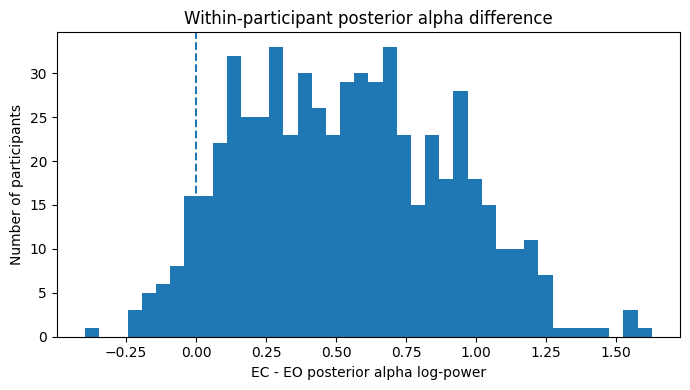

In [12]:
if RECORDING_FEATURES_FILE.exists():
    included = recording_features[recording_features["include"]].copy()

    alpha_wide = included.pivot(
        index="participant_id",
        columns="condition",
        values="posterior_alpha_log",
    ).dropna()

    alpha_wide["EC_minus_EO"] = alpha_wide["EC"] - alpha_wide["EO"]

    print("Participants with both features:", len(alpha_wide))
    print("Proportion with EC > EO:", (alpha_wide["EC_minus_EO"] > 0).mean())
    display(alpha_wide["EC_minus_EO"].describe())

    plt.figure(figsize=(7, 4))
    plt.hist(alpha_wide["EC_minus_EO"], bins=40)
    plt.axvline(0, linestyle="--")
    plt.xlabel("EC - EO posterior alpha log-power")
    plt.ylabel("Number of participants")
    plt.title("Within-participant posterior alpha difference")
    plt.tight_layout()

    plt.savefig(FIGURES_DIR / "posterior_alpha_ec_minus_eo_hist.png", dpi=300)
    plt.show()


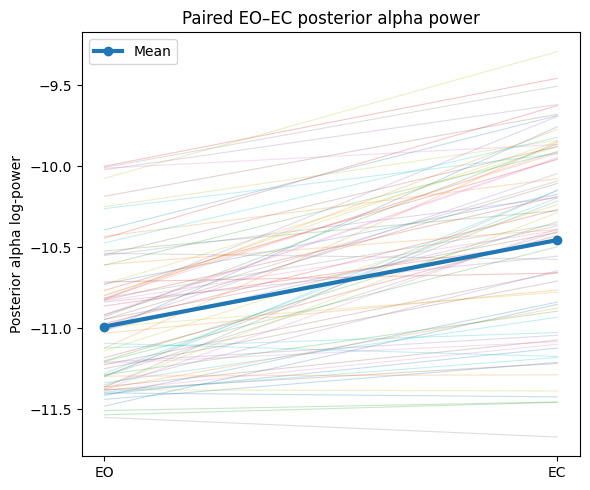

In [13]:
if RECORDING_FEATURES_FILE.exists():
    # Paired line plot for a random subset, so the figure is readable.
    rng = np.random.default_rng(42)
    plot_subjects = rng.choice(alpha_wide.index, size=min(80, len(alpha_wide)), replace=False)

    plot_df = (
        included[included["participant_id"].isin(plot_subjects)]
        .copy()
    )

    condition_order = {"EO": 0, "EC": 1}
    plot_df["x"] = plot_df["condition"].map(condition_order)

    plt.figure(figsize=(6, 5))

    for participant_id, group in plot_df.groupby("participant_id"):
        group = group.sort_values("x")
        plt.plot(
            group["x"],
            group["posterior_alpha_log"],
            alpha=0.25,
            linewidth=0.8,
        )

    means = (
        included.groupby("condition")["posterior_alpha_log"]
        .mean()
        .reindex(["EO", "EC"])
    )

    plt.plot([0, 1], means.values, marker="o", linewidth=3, label="Mean")
    plt.xticks([0, 1], ["EO", "EC"])
    plt.ylabel("Posterior alpha log-power")
    plt.title("Paired EO–EC posterior alpha power")
    plt.legend()
    plt.tight_layout()

    plt.savefig(FIGURES_DIR / "paired_posterior_alpha_lines.png", dpi=300)
    plt.show()
